In [1]:
import sys
sys.path.insert(0, "../src")
from data_cleaner import DataCleaner
from encoder import TargetEncoder
from sampler import oversample
from evaluator import evaluate_model
from value_grouper import ValueGrouper

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline


pd.set_option('display.max_columns', None) # show full dataframe


In [2]:
# import data
X = pd.read_csv("../data/training_set_values.csv")
y = pd.read_csv("../data/training_set_labels.csv")


data = pd.merge(X, y, on="id")

# data = value_manipulation(data)
# extra_keep = list(data["funder"].unique())

cleaner = DataCleaner()
cleaned_data = cleaner.preprocess(data)


cleaned_X = cleaned_data.drop(columns=["status_group", "id"])
cleaned_y = cleaned_data["status_group"]


2025-12-02 16:28:32,482 - INFO - Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
2025-12-02 16:28:32,490 - INFO - Data cleaning completed.


In [3]:
# split data into train and test data
X_train, X_test, y_train, y_test = train_test_split(cleaned_X, cleaned_y)

### Create pipeline (Encoding -> Model and hyperparemter setting) and train model

In [4]:
from imblearn.over_sampling import SMOTE

In [ ]:
# define encoding stream for features 
# cat_cols = ["quantity_group", "region", "payment_type",
#             "extraction_type_class", "management", "quality_group"]
cat_cols = ["quantity_group", "region", "extraction_type_class", "source", "basin", "payment_type"]

num_cols = ["pump_age", "gps_height"]


categorical_transformer = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# define the model and controlable parameters
param_dist = {
  'model__n_estimators': [435, 436, 437, 438, 439, 440],
  # 'model__n_estimators': [439, 440, 441, 442, 443, 444],
  'model__max_depth': [13, 14, 15, 16, 17],
  'model__min_samples_split': [7, 8, 9, 10, 11],
  'model__min_samples_leaf': [1, 2, 3, 4, 5]
}

# encode target value separately
y_train = TargetEncoder().fit_transform(y_train)
y_test = TargetEncoder().transform(y_test)

# Create a random forest classifier
classifier = RandomForestClassifier(random_state=42, n_jobs=-1)


# Create the encoding and training pipeline
pipeline = Pipeline([
  # ("group", ValueGrouper(col="installer", N=10)),
                      ("encode", preprocessor),
                     ("smote", SMOTE()),
                    ("model", classifier)])

random_search = RandomizedSearchCV(
  pipeline, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42, return_train_score=True,
  verbose=3, error_score='raise'
)



In [6]:
# train model
random_search.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [13, 14, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [7, 8, ...], 'model__n_estimators': [435, 436, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,'raise'


In [ ]:
# import pickle

# # save
# with open('../output/checkpoint/5_source_basin_payment_gps.pkl','wb') as f:
#     pickle.dump(random_search,f)

### Test and interpret model

In [8]:
# import pickle
# # load
# with open('../output/checkpoint/4_basin_payment.pkl', 'rb') as f:
#     checkpoint = pickle.load(f)

In [9]:
# if I preprocess input manually, .transform() not .fit_transform()
prediction = random_search.predict(X_test)

In [10]:
prediction.shape

(14848,)

### Interpret model

In [11]:
importances = random_search.best_estimator_.named_steps['model'].feature_importances_
feature_name = random_search.best_estimator_.named_steps['encode'].get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature": feature_name,
    "importance": importances
}).sort_values("importance", ascending=False)

In [12]:
feat_imp.head(20)

,feature,importance
0,cat__quantity_group_dry,0.131462
59,num__pump_age,0.070144
60,num__gps_height,0.057875
1,cat__quantity_group_enough,0.056771
29,cat__extraction_type_class_other,0.056102
26,cat__extraction_type_class_gravity,0.044823
54,cat__payment_type_never pay,0.039324
2,cat__quantity_group_insufficient,0.034550
39,cat__source_river,0.032912
27,cat__extraction_type_class_handpump,0.027658


In [13]:
grouped_feat_imp = feat_imp.copy()
grouped_feat_imp['prefix'] = grouped_feat_imp['feature'].str.extract(r'^([A-Za-z]+[_]+[A-Za-z]+[_])')
grouped_feat_imp = grouped_feat_imp.groupby('prefix')['importance'].mean()
grouped_feat_imp = pd.DataFrame(grouped_feat_imp).sort_values(by="importance", ascending=False)
grouped_feat_imp

,importance
prefix,
num__pump_,0.070144
num__gps_,0.057875
cat__quantity_,0.048078
cat__extraction_,0.021191
cat__payment_,0.017675
cat__basin_,0.011165
cat__source_,0.011128
cat__region_,0.007036


In [14]:
res = pd.DataFrame.from_dict(random_search.cv_results_)
res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,94.993375,3.803077,2.673054,2.006520,437,11,2,16,"{'model__n_estimators': 437, 'model__min_sampl...",0.736446,0.732181,0.737344,0.725752,0.725191,0.731383,0.005135,1,0.757114,0.758489,0.755683,0.756980,0.755970,0.756847,0.000991
1,95.851736,2.573984,1.742191,0.483967,438,11,2,15,"{'model__n_estimators': 438, 'model__min_sampl...",0.733191,0.728252,0.733191,0.722833,0.725191,0.728532,0.004174,5,0.751361,0.752231,0.749284,0.750807,0.753445,0.751426,0.001393
2,89.958823,2.938221,3.053249,1.511983,436,9,5,13,"{'model__n_estimators': 436, 'model__min_sampl...",0.718038,0.716130,0.717477,0.710373,0.710597,0.714523,0.003356,10,0.725908,0.726890,0.724308,0.727964,0.726701,0.726354,0.001215
3,91.251825,2.518597,3.004618,1.716718,439,8,4,14,"{'model__n_estimators': 439, 'model__min_sampl...",0.724773,0.722079,0.725334,0.715088,0.712955,0.720046,0.005085,8,0.735393,0.737835,0.735028,0.736635,0.736130,0.736204,0.000989
4,90.790528,3.575203,2.659602,1.951503,440,11,5,14,"{'model__n_estimators': 440, 'model__min_sampl...",0.721854,0.718599,0.721854,0.714189,0.711046,0.717509,0.004283,9,0.731100,0.731661,0.733036,0.733745,0.731893,0.732287,0.000964
5,95.547932,0.974482,1.781032,0.990060,437,10,3,17,"{'model__n_estimators': 437, 'model__min_sampl...",0.734538,0.731732,0.737457,0.725640,0.725752,0.731024,0.004712,2,0.757114,0.756777,0.753354,0.755634,0.755072,0.755590,0.001342
6,91.935841,3.887903,2.949108,1.887200,435,8,2,15,"{'model__n_estimators': 435, 'model__min_sampl...",0.735324,0.732181,0.732405,0.721935,0.725079,0.729385,0.005025,4,0.754252,0.752680,0.750379,0.752238,0.753276,0.752565,0.001285
7,93.917820,0.831544,1.780045,0.411407,440,7,1,14,"{'model__n_estimators': 440, 'model__min_sampl...",0.733416,0.729263,0.734538,0.724181,0.726762,0.729632,0.003911,3,0.757367,0.755683,0.754981,0.756335,0.758075,0.756488,0.001116
8,92.740376,3.887378,3.621502,1.753050,435,10,3,16,"{'model__n_estimators': 435, 'model__min_sampl...",0.734201,0.729150,0.732742,0.723170,0.722272,0.728307,0.004857,6,0.753157,0.751249,0.749621,0.750807,0.751649,0.751297,0.001152
9,68.385648,33.636020,1.310347,0.765651,439,9,5,17,"{'model__n_estimators': 439, 'model__min_sampl...",0.730497,0.727130,0.729599,0.723282,0.721262,0.726354,0.003568,7,0.746871,0.747769,0.743419,0.746934,0.748253,0.746649,0.001696


<Axes: >

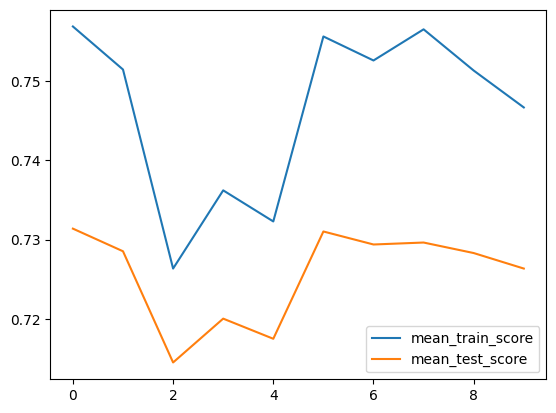

In [15]:
res["mean_train_score"].plot(kind="line", legend=True)
res["mean_test_score"].plot(kind="line", legend=True)

                         precision    recall  f1-score   support

         non functional       0.84      0.68      0.75      5727
functional needs repair       0.28      0.47      0.35      1065
             functional       0.77      0.80      0.79      8056

               accuracy                           0.73     14848
              macro avg       0.63      0.65      0.63     14848
           weighted avg       0.76      0.73      0.74     14848



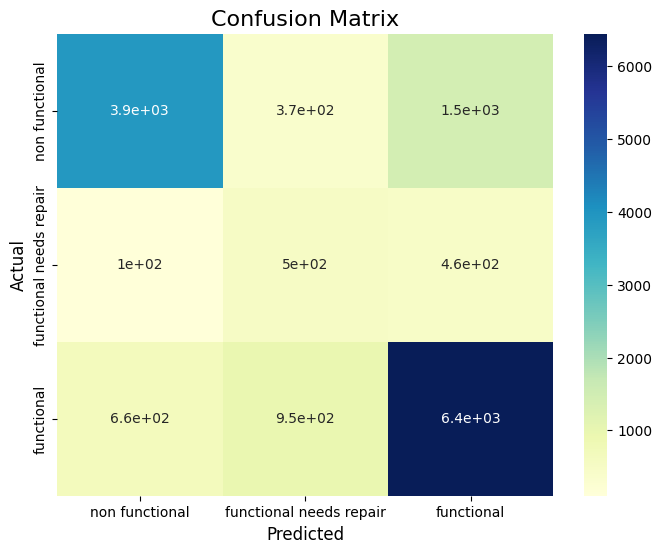

In [16]:
list_prediction = prediction.tolist()
list_y_test = y_test.tolist()

evaluate_model(list_y_test, list_prediction)

### try with all data

In [17]:
all_data = pd.merge(X, y, on="id")

In [18]:
clean = DataCleaner()
cleaned_all_data = clean.preprocess(all_data)

2025-12-02 16:39:28,615 - INFO - Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
2025-12-02 16:39:28,622 - INFO - Data cleaning completed.


In [19]:
X_all = cleaned_all_data.drop(["status_group", "id"], axis=1)
y_all = cleaned_all_data["status_group"]

In [20]:
y_all = TargetEncoder().transform(y_all)

In [21]:
prediction_all = random_search.predict(X_all)

                         precision    recall  f1-score   support

         non functional       0.85      0.70      0.77     22819
functional needs repair       0.30      0.52      0.38      4317
             functional       0.79      0.81      0.80     32255

               accuracy                           0.75     59391
              macro avg       0.65      0.68      0.65     59391
           weighted avg       0.78      0.75      0.76     59391



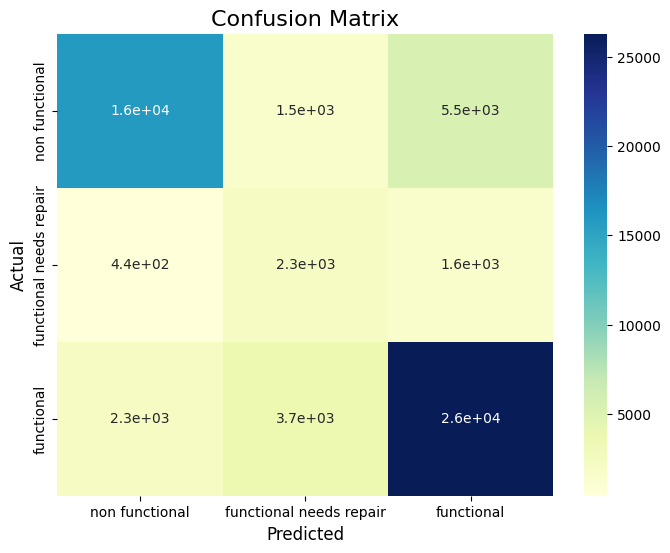

In [22]:
list_prediction_all = prediction_all.tolist()
list_y_all = y_all.tolist()

evaluate_model(list_y_all, list_prediction_all)